In [ ]:
#| default_exp pr_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Pairwise Relation Between Multiple Embeddings of Time Series
> A non‑clustered pairwise‑relation heatmap is simply a matrix‑style visualization that displays a **pairwise score** between each pair of time series without reordering them.

> Pairwise scores include:
>
>- *dynamic timer warping alignment*, 
>- *distance correlation*.


In [ ]:
#| eval: false
from fhemb.utils.cutils import depict_DTW, plot_pr_heatmap 

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-04 17:48:51.725064: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more

## Diagnostics via Heatmaps
> covers matrix‑level pathologies visible directly in the pairwise‑relation heatmap:

>- Diagonal sanity — zeros (distance) or ones (similarity)
>- Symmetry — off‑diagonal mismatch reveals implementation errors
>- Banding — ordering‑dependent structure; local continuity
>- Block structure — natural grouping or segmentation
>- Outlier rows/columns — anomalous or corrupted time series
>- Range compression — measure uninformative for this dataset
>- Color‑scale skew — dominance of extremes hiding structure
>- Missing‑value patterns — NA stripes or blocks
>- Ordering artifacts — abrupt diagonal jumps

In [ ]:
#| eval: false

from nbdev_fhemb.module_functions_ex import Xdm

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

### Distance correlation

::: {.callout-note title="What distance correlation emphasizes for 1D time series"}
Distance correlation (biased V‑statistic) emphasizes:

- any nonlinear dependence — captures relationships beyond linear or monotonic trends
- joint variation in amplitude — large differences contribute strongly via Euclidean distances
- shared temporal structure — responds to co‑movement even when shapes are not aligned
- global and local dependence — sensitive to both fine‑scale and broad‑scale co‑variation
- non‑monotonic patterns — detects curved, cyclic, or branched relationships
- distribution‑free association — equals zero only under independence, regardless of marginal shapes

Selecting distance correlation as the pairwise measure prioritizes general nonlinear dependence between 1D time series, making it a robust baseline for relation matrices.
:::

 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 2080/2080 [00:25<00:00, 81.51it/s] 


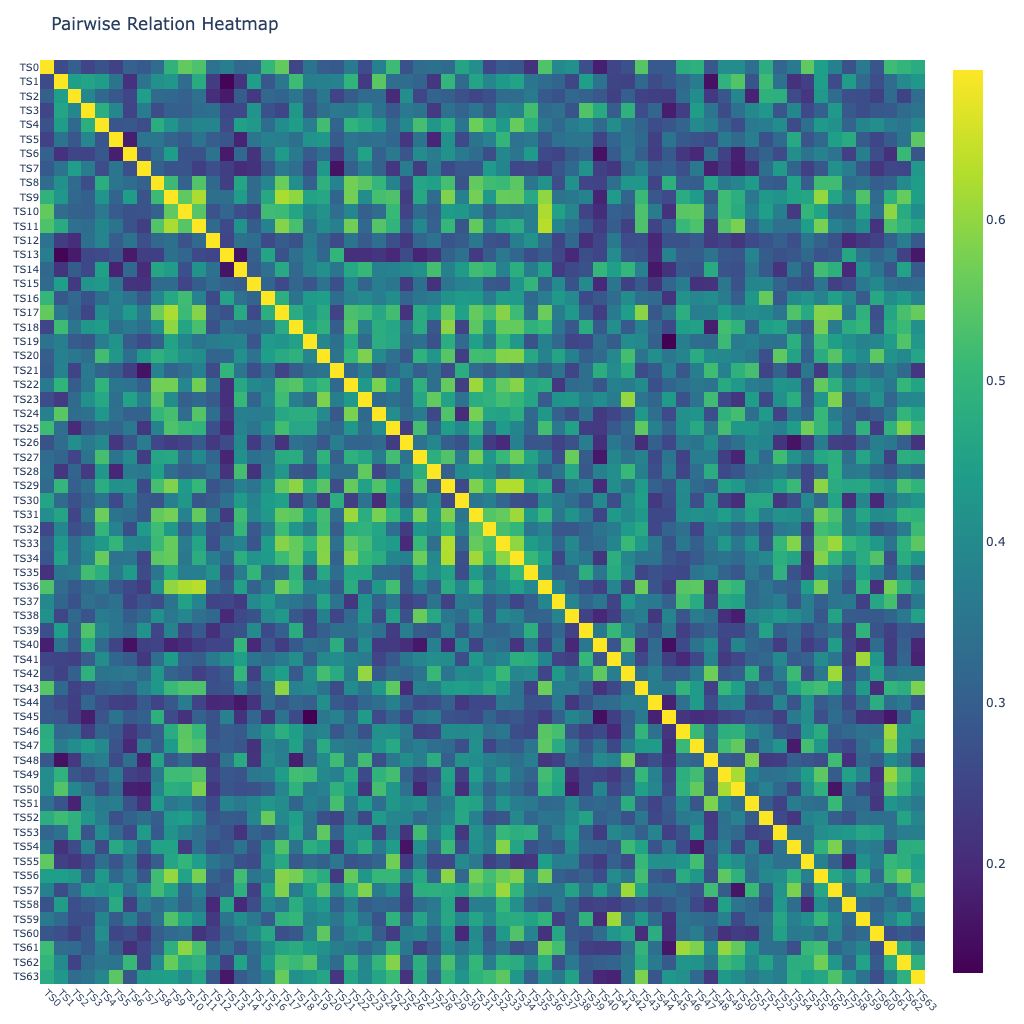

In [ ]:
#| eval: false

plot_pr_heatmap(
    Xdm,                       # data matrix (64 x timesteps) 
    alignment_type='dcor',     # distance correlation alignment
    normalize='log',           # normalization method for the distance correlation matrix
    n_jobs=8,                  # number of jobs for parallelization
    base_size=16               # base pixel size
) 

### Dynamic time warping alignment
> Dynamic Time Warping (DTW) is a method for aligning two time series by allowing non-linear stretching or compression along their temporal axes. 

> Instead of comparing the signals point-by-point, DTW finds an optimal warping path that brings similar patterns into alignment, even when they occur at different speeds or with local temporal distortions. The amount of warping required - measured with respect to a chosen distance metrics - serves as a quantitative measure of dissimilarity between the two time series. This makes DTW particularly useful for comparing signals whose shapes are similar but not temporally synchronized.

::: {.callout-note title="Alignment metrics for DTW — What they measure"}
DTW can operate with different point‑wise distance metrics, each defining how local differences between two time‑series samples are evaluated. Choosing a metric determines what "local similarity" means inside DTW, allowing the clustering to emphasize amplitude, shape, correlation, or categorical differences depending on the application.
:::

In [ ]:
#| eval: false
from scipy.spatial.distance import (
    euclidean, 
    cityblock, 
    cosine, 
    mahalanobis, 
    sqeuclidean, 
    chebyshev, 
    minkowski, 
    braycurtis, 
    canberra, 
    correlation, 
    jaccard, 
    hamming
)

::: {.callout-note title="Choosing a Distance Metric for DTW"}
Different metrics emphasize different aspects of local similarity inside DTW:

- **euclidean** / **sqeuclidean** - best when absolute amplitude differences matter
- **cityblock** / **minkowski** - robust to outliers; good for piecewise‑linear or sparse changes
- **cosine** / **correlation** - focus on shape rather than magnitude; useful when scaling varies
- **chebyshev** - highlights the single largest deviation; good for threshold‑type signals
- **braycurtis** / **canberra** - emphasize relative changes; useful when values vary across orders of magnitude
- **hamming** / **jaccard** - for categorical or binary time series
- **mahalanobis** - accounts for covariance structure when dimensions are correlated

Selecting a metric determines whether DTW prioritizes amplitude, shape, relative variation, or categorical differences, allowing the clustering to match the structure of your data.
:::

 [INFO] cutils.calc_pairwise_relation: Using cosine alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 2080/2080 [05:29<00:00,  6.31it/s]


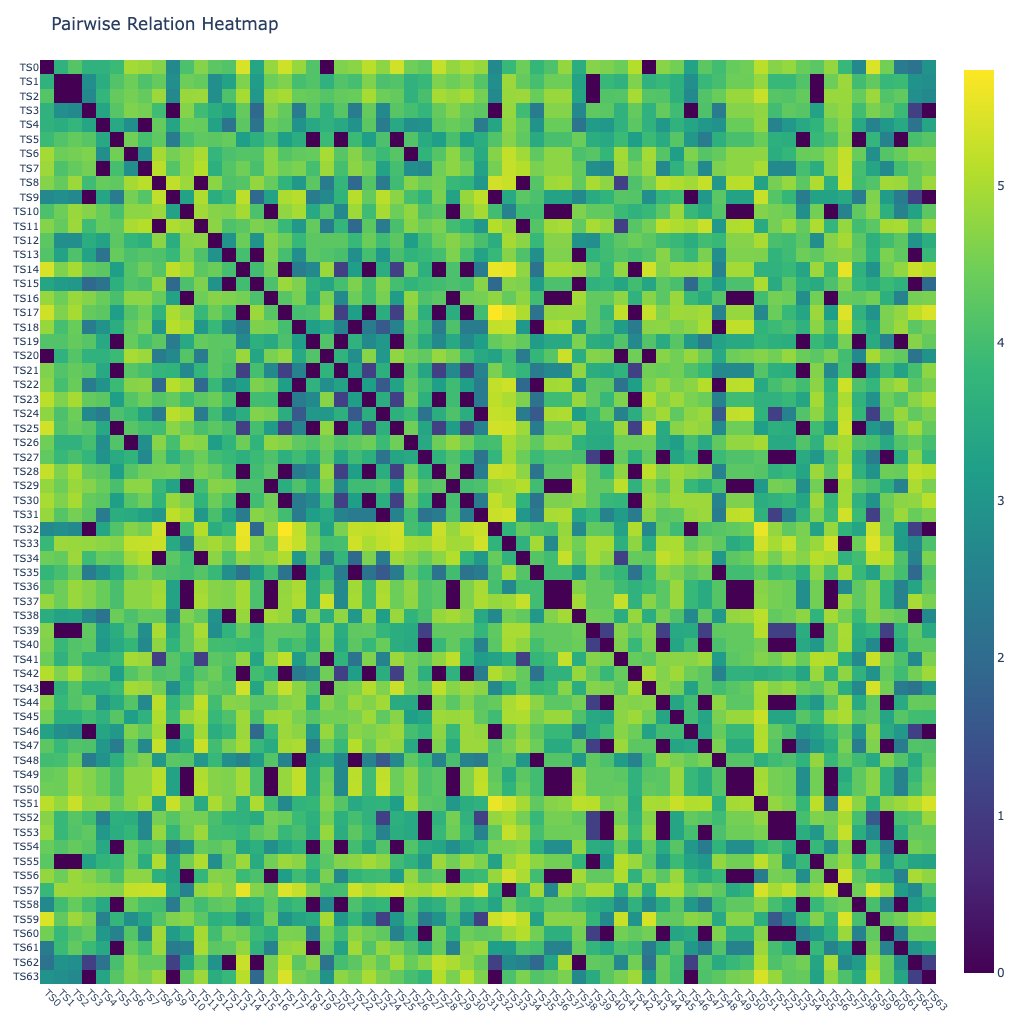

In [ ]:
#| eval: false

plot_pr_heatmap(
    Xdm,                       # data matrix (64 x timesteps) 
    alignment_type='fastdtw',  # 'dcor', 'fastdtw'(euclidean), 'tslearn_dtw'(euclidean), 'soft_dtw'(sqeuclidean), 'soft_dtw_div'
    dist=cosine,               # alignment metric function used inside fastdtw
    radius=10,                 # refinement window size in fastdtw
    normalize='log',           # normalization method for the matrix of DTW alignment 
    n_jobs=8,                  # number of jobs for parallelization
    base_size=16               # base pixel size
)  

::: {.callout-note title="Non‑clustered heatmap diagnostics (Synchronized time series)"}
It helps assess whether the dataset contains meaningful similarity structure before clustering:

- **Uniform appearance** (no visible structure): All time series behave similarly or differences are weak; clustering may not reveal strong groups.
- **Clear stripes** (horizontal or vertical): A specific time series is consistently different from all others — an outlier or atypical subject/channel.
- **Gradients or smooth transitions along the diagonal**: The ordering of the time series reflects a systematic progression (e.g., subjects sorted by condition, intensity).
- **Patchy or noisy texture**: Indicates heterogeneous data quality or inconsistent preprocessing across time series.
- **Large global brightness**: Distances are high overall — time series differ strongly; normalization or scaling may need adjustment.
- **Symmetry check**: The matrix must be symmetric; deviations indicate metric or implementation issues.

This view reveals whether synchronized time series naturally separate into similarity groups, contain outliers, or require preprocessing adjustments before clustering.
:::

::: {.callout-caution title="Diagonal values"}
When the radius is very small (e.g., $\ll 10$), FastDTW restricts the warping window too aggressively. This can force suboptimal alignments, causing unusually large diagonal values in the local cost matrix. These spikes are an artefact of the FastDTW approximation rather than properties of the underlying data.
:::

::: {.callout-important title="Pairwise relation embedding"}
The pairwise relation matrix is computed over embedded time series (*primary embedding*). A row of this matrix defines a second order embedding: the vector of pairwise relations of a given embedded time series to all other embedded time series. Thus, this *pairwise relationship embedding* is determined jointly by the primary embedding, `alignment_type`, `normalize`, and  `dist`, `radius` if applicable.
:::

#### Zoom in on DTW alignment between two time series

In [ ]:
#| eval: false
from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [WARNING] embedding.get_ts_subjs_ftr: Feature pc0 not in features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature pc0 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('pc0', 'pc1', 'pc2

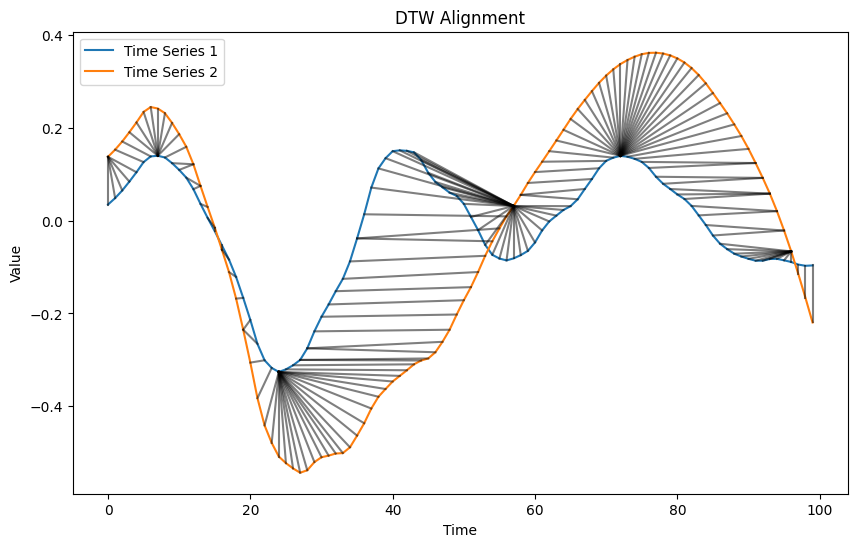

In [ ]:
#| eval: false

depict_DTW(
    emb_prj_decomp_rec1.get_df_ts_subjs('pc0')['pcomponents_ts']['subj50'][:100], 
    emb_prj_decomp_rec1.get_df_ts_subjs('pc0')['pcomponents_ts']['subj51'][:100],
    dist=euclidean
)

::: {.callout-note title="DTW alignment of embeddings - What it shows"}
DTW alignment reveals similarity even if events occur a bit earlier or later across synchronized time series.
:::